# Toy Squares Base DP Evaluation

This notebook evaluates a trained base Diffusion Policy checkpoint on **Early Decision** and **Late Decision** toy scenarios (100 rollouts each), and includes a fixed-action environment sanity check GIF.

In [1]:
import json
import random
from pathlib import Path

import imageio
import numpy as np
import torch

import robomimic
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.torch_utils as TorchUtils

# Ensure custom gym envs are registered
import robomimic.envs

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

def jiggle(deterministic=False):
    if deterministic:
        return 0.0
    return 2.0 * (np.random.random() - 0.5)

def early_decision_cube_setup(deterministic=False):
    cube_1 = [128 + 90 * jiggle(deterministic), 128 + 90 * jiggle(deterministic)]
    cube_2 = [128 + 90 * jiggle(deterministic), 384 + 90 * jiggle(deterministic)]
    cube_4 = [384 + 90 * jiggle(deterministic), 128 + 90 * jiggle(deterministic)]
    cube_3 = [384 + 90 * jiggle(deterministic), 384 + 90 * jiggle(deterministic)]
    agent = [255 + 70 * jiggle(deterministic), 255 + 70 * jiggle(deterministic)]

    cube_list = [cube_1, cube_2, cube_3, cube_4]
    if not deterministic:
        random.shuffle(cube_list)

    loc_list = [agent]
    loc_list.extend(cube_list)
    rand_rots = np.random.rand(4) * 2 * np.pi - np.pi
    loc_list.append(rand_rots)
    return np.concatenate(loc_list)

def late_decision_cube_setup(deterministic=False):
    cube_1 = [100, 340 + 25 * jiggle(deterministic)]
    cube_2 = [100, 420 + 25 * jiggle(deterministic)]
    cube_3 = [150 + 25 * jiggle(deterministic), 460]
    cube_4 = [230 + 25 * jiggle(deterministic), 460]
    agent = [420 + 70 * jiggle(deterministic), 120 + 70 * jiggle(deterministic)]

    cube_list = [cube_1, cube_2, cube_3, cube_4]
    if not deterministic:
        random.shuffle(cube_list)

    loc_list = [agent]
    loc_list.extend(cube_list)
    rand_rots = np.random.rand(4) * 2 * np.pi - np.pi
    loc_list.append(rand_rots)
    return np.concatenate(loc_list)

/home/mzoellner/miniconda3/envs/guided-diffusion/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
# Set this to your trained base DP checkpoint
DP_CKPT_PATH = "/absolute/path/to/model_epoch_XXXX.pth"

assert Path(DP_CKPT_PATH).exists(), f"Checkpoint not found: {DP_CKPT_PATH}"

device = TorchUtils.get_torch_device(try_to_use_cuda=False)
policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=DP_CKPT_PATH, device=device, verbose=True)
env, _ = FileUtils.env_from_checkpoint(ckpt_dict=ckpt_dict, render=False, render_offscreen=True, verbose=True)

print("Loaded policy and environment successfully.")
print("Environment type:", type(env))

In [ ]:
def run_rollout(policy, env, setup_fn, horizon=200):
    setup_state = setup_fn(deterministic=False)
    obs = env.reset_to(setup_state)
    policy.start_episode()

    total_reward = 0.0
    success = False
    steps = 0

    for t in range(horizon):
        act = policy(ob=obs)
        obs, r, done, info = env.step(act)
        total_reward += float(r)
        steps = t + 1
        if r > 0:
            success = True
        if done or success:
            break

    return {"success": float(success), "steps": steps, "return": total_reward}

def evaluate_scenario(policy, env, setup_fn, n_rollouts=100, horizon=200):
    records = [run_rollout(policy, env, setup_fn, horizon=horizon) for _ in range(n_rollouts)]
    success_rate = float(np.mean([r["success"] for r in records]))
    avg_steps = float(np.mean([r["steps"] for r in records]))
    avg_return = float(np.mean([r["return"] for r in records]))
    return {
        "n_rollouts": n_rollouts,
        "success_rate": success_rate,
        "avg_steps": avg_steps,
        "avg_return": avg_return,
        "records": records,
    }

early_results = evaluate_scenario(policy, env, early_decision_cube_setup, n_rollouts=100, horizon=200)
late_results = evaluate_scenario(policy, env, late_decision_cube_setup, n_rollouts=100, horizon=200)

print("Early Decision:", {k: v for k, v in early_results.items() if k != "records"})
print("Late Decision:", {k: v for k, v in late_results.items() if k != "records"})

In [ ]:
out_path = Path("toy_squares/early_late_eval_results.json")
out_path.parent.mkdir(parents=True, exist_ok=True)

summary = {
    "checkpoint": DP_CKPT_PATH,
    "early_decision": {k: v for k, v in early_results.items() if k != "records"},
    "late_decision": {k: v for k, v in late_results.items() if k != "records"},
}

out_path.write_text(json.dumps(summary, indent=2))
print(f"Saved summary to {out_path}")

/home/mzoellner/miniconda3/envs/guided-diffusion/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/mzoellner/miniconda3/envs/guided-diffusion/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:20: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float32. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/home/mzoellner/miniconda3/envs/guided-diffusion/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:25: UserWarning: WARN: It seems a Box observation space is an image but the upper and lower bounds are not in [0, 255]. Gen

Saved sanity GIF to toy_squares/sanity_fixed_action.gif


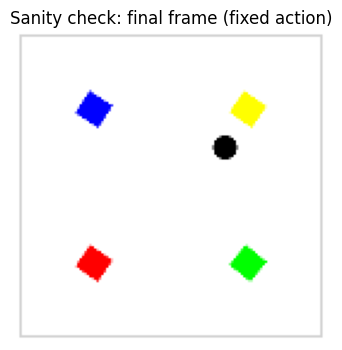

In [2]:
import gym
import matplotlib.pyplot as plt

sanity_env = gym.make("TouchCube")
obs = sanity_env.reset(state=early_decision_cube_setup(deterministic=True))

frames = [sanity_env.render(mode="rgb_array", height=256, width=256)]
hardcoded_action = np.array([0.35, -0.25], dtype=np.float32)
for _ in range(35):
    obs, r, d, info = sanity_env.step(hardcoded_action)
    frames.append(sanity_env.render(mode="rgb_array", height=256, width=256))

sanity_gif = Path("toy_squares/sanity_fixed_action.gif")
sanity_gif.parent.mkdir(parents=True, exist_ok=True)
imageio.mimsave(sanity_gif, frames, fps=10)

plt.figure(figsize=(4, 4))
plt.imshow(frames[-1])
plt.axis("off")
plt.title("Sanity check: final frame (fixed action)")
print(f"Saved sanity GIF to {sanity_gif}")